### Phase 1. Data Analysis and Processing
#### Initial Analysis for hydride formula and Capacity Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [2]:
raw_data_path = r"D:\Hydride_Machine_learning_project\Machine_Model\data\raw\hydride_data.csv"  
report_path = r"D:\Hydride_Machine_learning_project\Machine_Model\reports"
figures_path = os.path.join(report_path, "figures", "raw_data_analysis")

In [3]:
os.makedirs(figures_path, exist_ok=True)

In [4]:
df_raw = pd.read_csv(raw_data_path)

In [7]:
df_raw.head(10)

,Composition,Alloy_class,Dataset,H2_W% (max),temperature(K),Citation
0,Mg1.5Ni1,Mg,HydPark,2.6,573,DOE_data_url
1,Mg0.872Al0.128,Mg,HydPark,6.7,625,DOE_data_url
2,Mg0.996Ni0.004,Mg,HydPark,4.6,573,DOE_data_url
3,Mg0.807Al0.193,Mg,HydPark,6.6,625,DOE_data_url
4,Mg0.879Ni0.121,Mg,HydPark,5.7,596,DOE_data_url
5,Mg0.882Cu0.118,Mg,HydPark,5.3,603,DOE_data_url
6,Mg0.874La0.021Ni0.105,Mg,HydPark,5.3,583,DOE_data_url
7,Mg0.874La0.021Ni0.105,Mg,HydPark,5.1,573,DOE_data_url
8,Mg0.748La0.042Ni0.21,Mg,HydPark,4.0,573,DOE_data_url
9,Mg0.733Zr0.089Fe0.124Cr0.053,Mg,HydPark,3.4,573,DOE_data_url


In [5]:
print(f"Loaded raw data with shape: {df_raw.shape}")
print("Raw data columns:", df_raw.columns.tolist())

Loaded raw data with shape: (1279, 6)
Raw data columns: ['Composition', 'Alloy_class', 'Dataset', 'H2_W% (max)', 'temperature(K)', 'Citation']


In [6]:
descriptive_stats = df_raw.describe(include='all').transpose()
descriptive_stats.to_csv(os.path.join(report_path, "raw_descriptive_stats.csv"))
print("Descriptive statistics saved to reports/raw_descriptive_stats.csv")

Descriptive statistics saved to reports/raw_descriptive_stats.csv


In [7]:
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_raw.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

Numeric columns: ['H2_W% (max)', 'temperature(K)']
Categorical columns: ['Composition', 'Alloy_class', 'Dataset', 'Citation']


In [8]:
missing_values = df_raw.isnull().sum()
missing_values
# missing_values.to_csv(os.path.join(report_path, "raw_missing_values.csv"))
# print("Missing values report saved to reports/raw_missing_values.csv")

Composition       0
Alloy_class       0
Dataset           0
H2_W% (max)       0
temperature(K)    0
Citation          0
dtype: int64

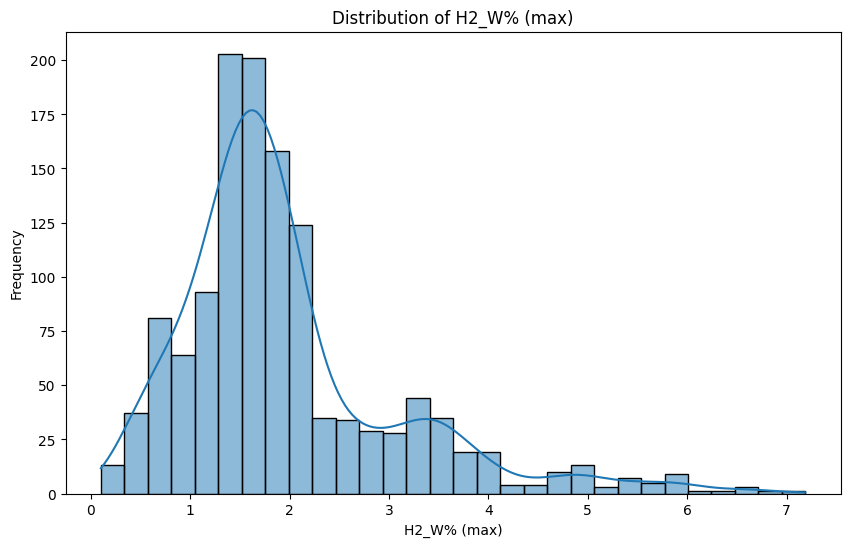

Target distribution plot saved to figures/raw_data_analysis/target_distribution.png
Normality test results saved to reports/raw_normality_test.txt


In [9]:
target_col = 'H2_W% (max)'
if target_col in df_raw.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_raw[target_col], bins=30, kde=True)
    plt.title(f'Distribution of {target_col}')
    plt.xlabel(target_col)
    plt.ylabel('Frequency')
    plt.savefig(os.path.join(figures_path, 'target_distribution.png'))
    plt.show()
    print("Target distribution plot saved to figures/raw_data_analysis/target_distribution.png")
    
    shapiro_test = stats.shapiro(df_raw[target_col].dropna())
    with open(os.path.join(report_path, "raw_normality_test.txt"), 'w') as f:
        f.write(f"Shapiro-Wilk Test for {target_col}: Statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")
    print("Normality test results saved to reports/raw_normality_test.txt")

Shapiro-Wilk Test for H2_W% (max): Statistic=0.8684, p-value=0.0000

Correlation matrix saved to reports/raw_correlation_matrix.csv


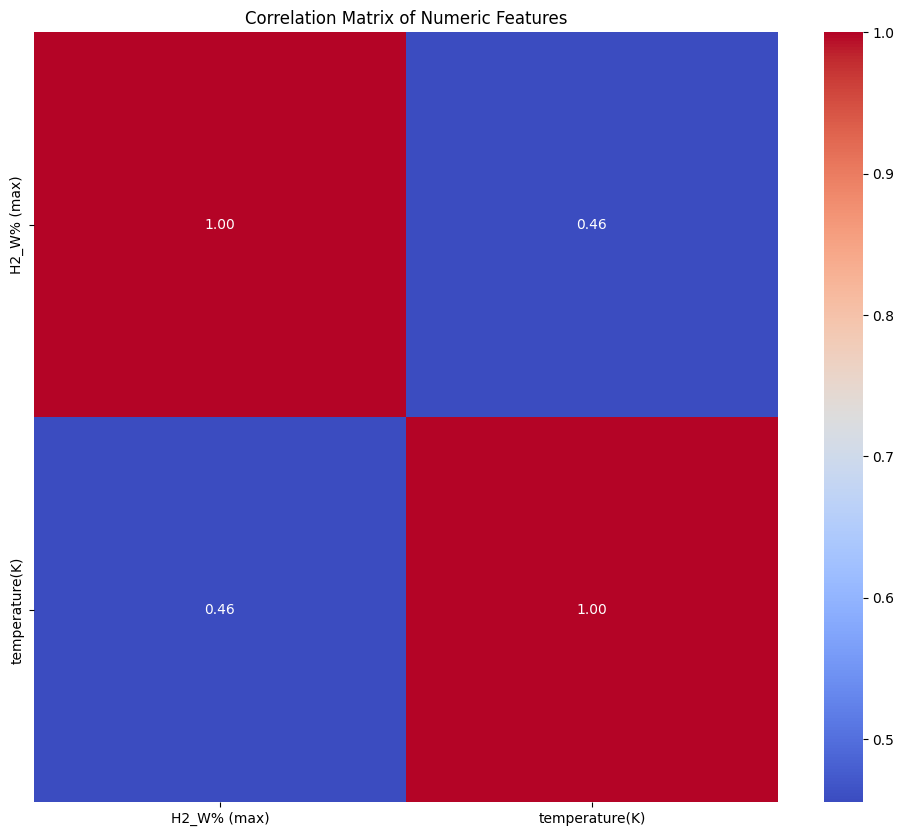

Correlation heatmap saved to figures/raw_data_analysis/correlation_matrix.png


In [10]:
if len(numeric_cols) > 1:
    corr_matrix = df_raw[numeric_cols].corr()
    corr_matrix.to_csv(os.path.join(report_path, "raw_correlation_matrix.csv"))
    print("Correlation matrix saved to reports/raw_correlation_matrix.csv")
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numeric Features')
    plt.savefig(os.path.join(figures_path, 'correlation_matrix.png'))
    plt.show()
    print("Correlation heatmap saved to figures/raw_data_analysis/correlation_matrix.png")

In [11]:
outliers_report = []
for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df_raw[col].dropna()))
    num_outliers = (z_scores > 3).sum()
    outliers_report.append({'Column': col, 'Num_Outliers': num_outliers})

outliers_df = pd.DataFrame(outliers_report)
outliers_df.to_csv(os.path.join(report_path, "raw_outliers_report.csv"), index=False)
print("Outliers report saved to reports/raw_outliers_report.csv")

Outliers report saved to reports/raw_outliers_report.csv


In [ ]:
key_numeric_cols = numeric_cols 
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_raw[key_numeric_cols])
plt.title('Boxplots for Key Numeric Features (Outlier Detection)')
plt.xticks(rotation=45)
plt.savefig(os.path.join(figures_path, 'boxplots_outliers.png'))
plt.close()
print("Boxplots for outliers saved to figures/raw_data_analysis/boxplots_outliers.png")

Boxplots for outliers saved to figures/raw_data_analysis/boxplots_outliers.png


In [13]:
if categorical_cols:
    for col in categorical_cols:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=col, data=df_raw)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.savefig(os.path.join(figures_path, f'{col}_distribution.png'))
        plt.close()
    print("Categorical distributions saved to figures/raw_data_analysis/")

Categorical distributions saved to figures/raw_data_analysis/


In [14]:
if target_col in numeric_cols:
    corr_with_target = df_raw[numeric_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
    corr_with_target.to_csv(os.path.join(report_path, "raw_correlation_with_target.csv"))
    print("Correlation with target saved to reports/raw_correlation_with_target.csv")
    
    plt.figure(figsize=(8, 6))
    corr_with_target.plot(kind='bar')
    plt.title(f'Correlation with {target_col}')
    plt.ylabel('Correlation Coefficient')
    plt.savefig(os.path.join(figures_path, 'correlation_with_target.png'))
    plt.close()
    print("Correlation with target plot saved to figures/raw_data_analysis/correlation_with_target.png")

Correlation with target saved to reports/raw_correlation_with_target.csv
Correlation with target plot saved to figures/raw_data_analysis/correlation_with_target.png


In [15]:
with open(os.path.join(report_path, "raw_data_summary.txt"), 'w') as f:
    f.write("Raw Data Analysis Summary\n")
    f.write(f"Shape: {df_raw.shape}\n")
    f.write(f"Numeric Columns: {len(numeric_cols)}\n")
    f.write(f"Categorical Columns: {len(categorical_cols)}\n")
    f.write(f"Missing Values Total: {missing_values.sum()}\n")
    f.write(f"Outliers Total: {outliers_df['Num_Outliers'].sum()}\n")

print("Raw data summary saved to reports/raw_data_summary.txt")
print("All analyses completed.")

Raw data summary saved to reports/raw_data_summary.txt
All analyses completed.


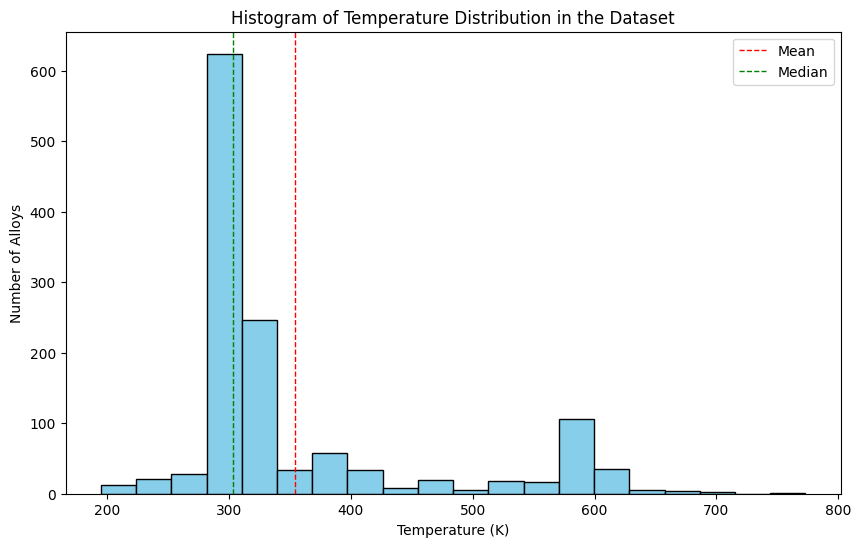

Temperature distribution histogram saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\temperature_histogram.png


In [16]:
# Histogram of temperature distribution (to show focus on temperatures near room temperature)
plt.figure(figsize=(10, 6))
plt.hist(df_raw['temperature(K)'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Temperature Distribution in the Dataset')
plt.xlabel('Temperature (K)')
plt.ylabel('Number of Alloys')
plt.axvline(df_raw['temperature(K)'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(df_raw['temperature(K)'].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
plt.legend()
plt.savefig(os.path.join(figures_path, 'temperature_histogram.png'))
plt.show()
print("Temperature distribution histogram saved at:", os.path.join(figures_path, 'temperature_histogram.png'))

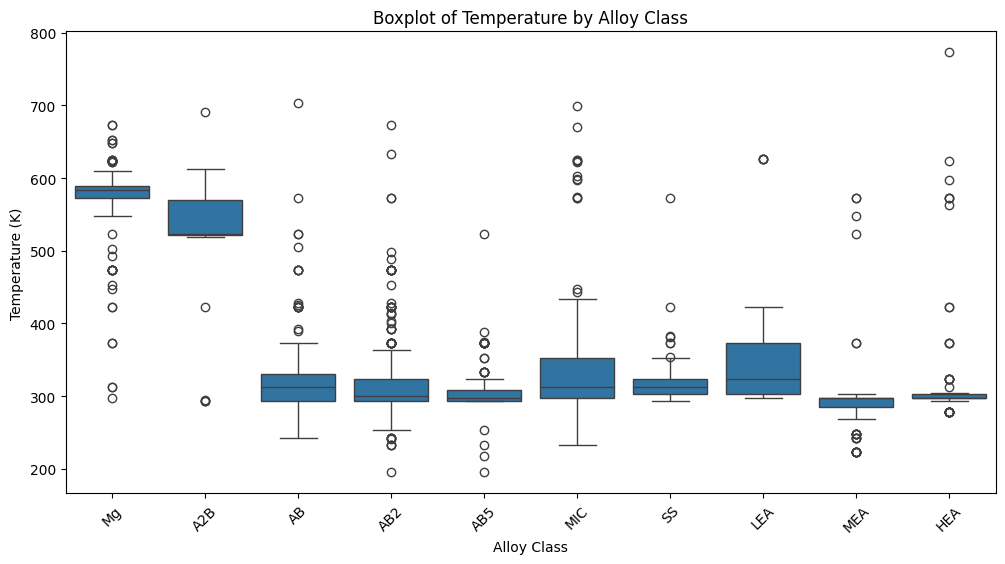

Boxplot of temperature by class saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\temperature_boxplot_by_class.png


In [17]:
# Boxplot of temperature by alloy class (for comparing thermal behaviors)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Alloy_class', y='temperature(K)', data=df_raw)
plt.title('Boxplot of Temperature by Alloy Class')
plt.xlabel('Alloy Class')
plt.ylabel('Temperature (K)')
plt.xticks(rotation=45)
plt.savefig(os.path.join(figures_path, 'temperature_boxplot_by_class.png'))
plt.show()
print("Boxplot of temperature by class saved at:", os.path.join(figures_path, 'temperature_boxplot_by_class.png'))

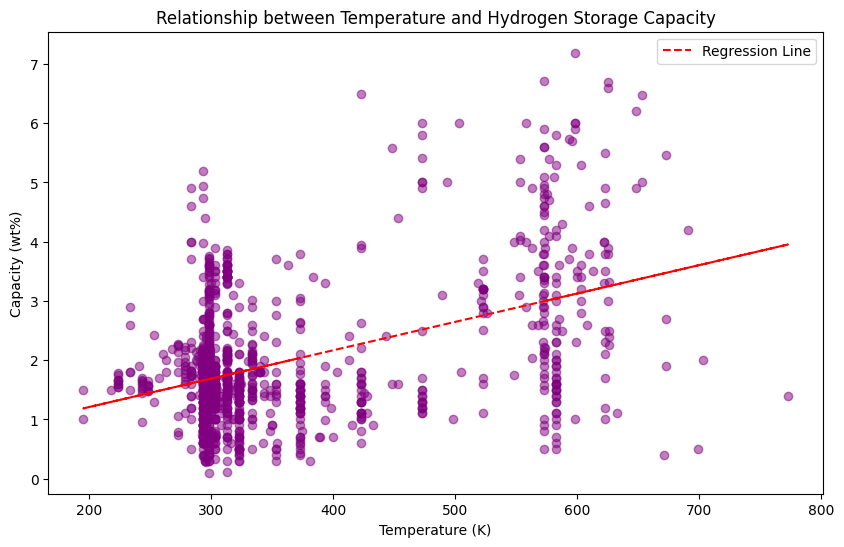

Scatter plot of temperature vs capacity saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\temperature_vs_capacity_scatter.png


In [19]:
# Scatter plot of relationship between temperature and storage capacity (to show moderate positive correlation)
plt.figure(figsize=(10, 6))
plt.scatter(df_raw['temperature(K)'], df_raw['H2_W% (max)'], alpha=0.5, color='purple')
plt.title('Relationship between Temperature and Hydrogen Storage Capacity')
plt.xlabel('Temperature (K)')
plt.ylabel('Capacity (wt%)')
# Add simple regression line
z = np.polyfit(df_raw['temperature(K)'], df_raw['H2_W% (max)'], 1)
p = np.poly1d(z)
plt.plot(df_raw['temperature(K)'], p(df_raw['temperature(K)']), "r--", label='Regression Line')
plt.legend()
plt.savefig(os.path.join(figures_path, 'temperature_vs_capacity_scatter.png'))
plt.show()
print("Scatter plot of temperature vs capacity saved at:", os.path.join(figures_path, 'temperature_vs_capacity_scatter.png'))

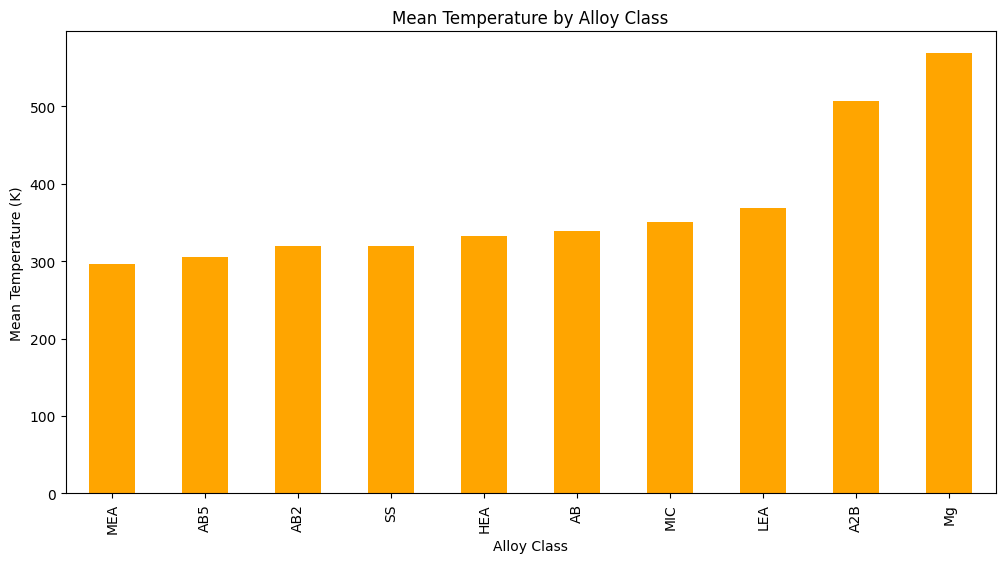

Bar chart of mean temperature saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\mean_temperature_by_class_bar.png


In [21]:
# Bar chart of mean temperature by alloy class (to highlight means)
mean_temp = df_raw.groupby('Alloy_class')['temperature(K)'].mean().sort_values()
plt.figure(figsize=(12, 6))
mean_temp.plot(kind='bar', color='orange')
plt.title('Mean Temperature by Alloy Class')
plt.xlabel('Alloy Class')
plt.ylabel('Mean Temperature (K)')
plt.savefig(os.path.join(figures_path, 'mean_temperature_by_class_bar.png'))
plt.show()
print("Bar chart of mean temperature saved at:", os.path.join(figures_path, 'mean_temperature_by_class_bar.png'))

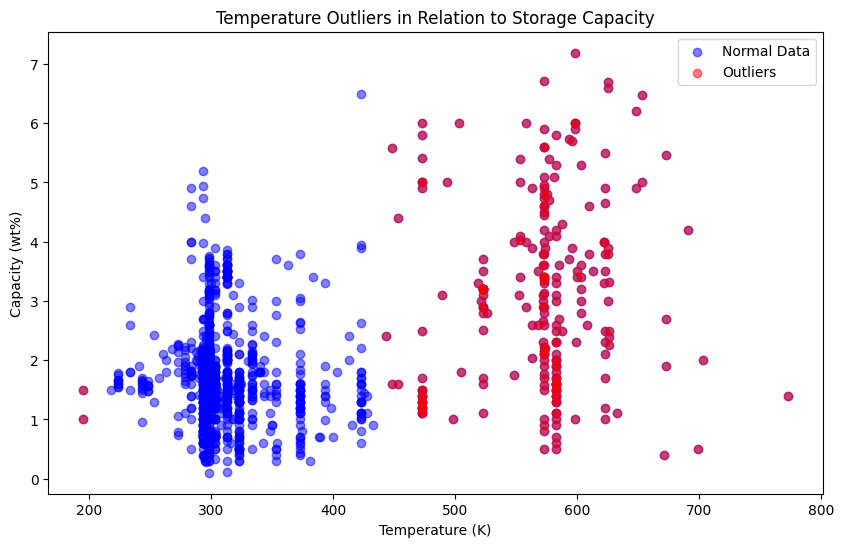

Scatter plot of temperature outliers saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\temperature_outliers_scatter.png


In [23]:
# Identify outliers with IQR and plot them
Q1 = df_raw['temperature(K)'].quantile(0.25)
Q3 = df_raw['temperature(K)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_raw[(df_raw['temperature(K)'] < (Q1 - 1.5 * IQR)) | (df_raw['temperature(K)'] > (Q3 + 1.5 * IQR))]

plt.figure(figsize=(10, 6))
plt.scatter(df_raw['temperature(K)'], df_raw['H2_W% (max)'], alpha=0.5, color='blue', label='Normal Data')
plt.scatter(outliers['temperature(K)'], outliers['H2_W% (max)'], alpha=0.5, color='red', label='Outliers')
plt.title('Temperature Outliers in Relation to Storage Capacity')
plt.xlabel('Temperature (K)')
plt.ylabel('Capacity (wt%)')
plt.legend()
plt.savefig(os.path.join(figures_path, 'temperature_outliers_scatter.png'))
plt.show()
print("Scatter plot of temperature outliers saved at:", os.path.join(figures_path, 'temperature_outliers_scatter.png'))

In [24]:
# Save outliers report as CSV similar to the notebook
outliers_report = [{'Column': 'temperature(K)', 'Num_Outliers': len(outliers)}]
outliers_df = pd.DataFrame(outliers_report)
outliers_df.to_csv(os.path.join(report_path, "raw_temperature_outliers_report.csv"), index=False)
print("Temperature outliers report saved at:", os.path.join(report_path, "raw_temperature_outliers_report.csv"))

Temperature outliers report saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\raw_temperature_outliers_report.csv


C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\2528802721.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Element', y='Mean_Temperature', data=element_df, palette='viridis', legend=True)


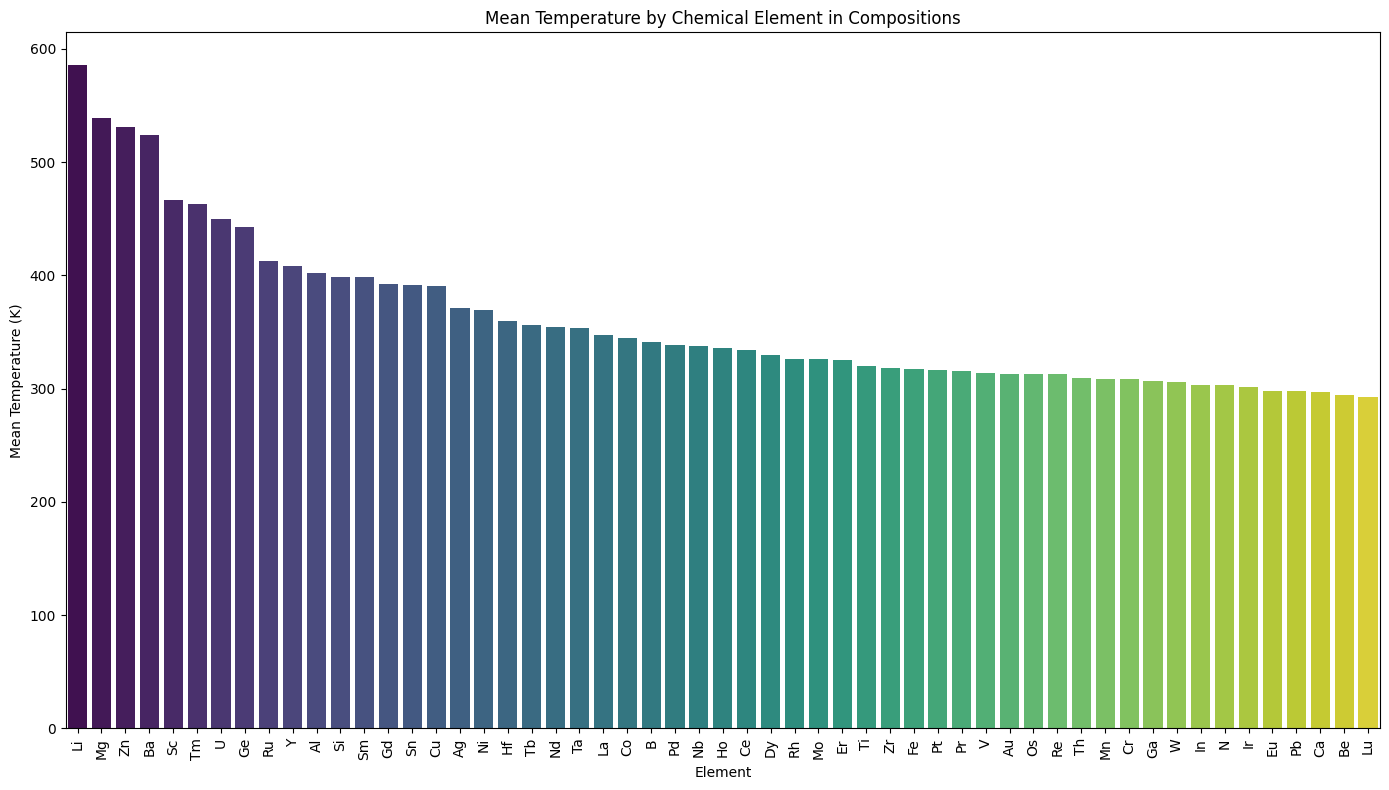

Bar chart of mean temperature by element saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\mean_temperature_by_element.png


C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\2528802721.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Element', y='Correlation_with_Temp', data=corr_df, palette='coolwarm', legend=True)


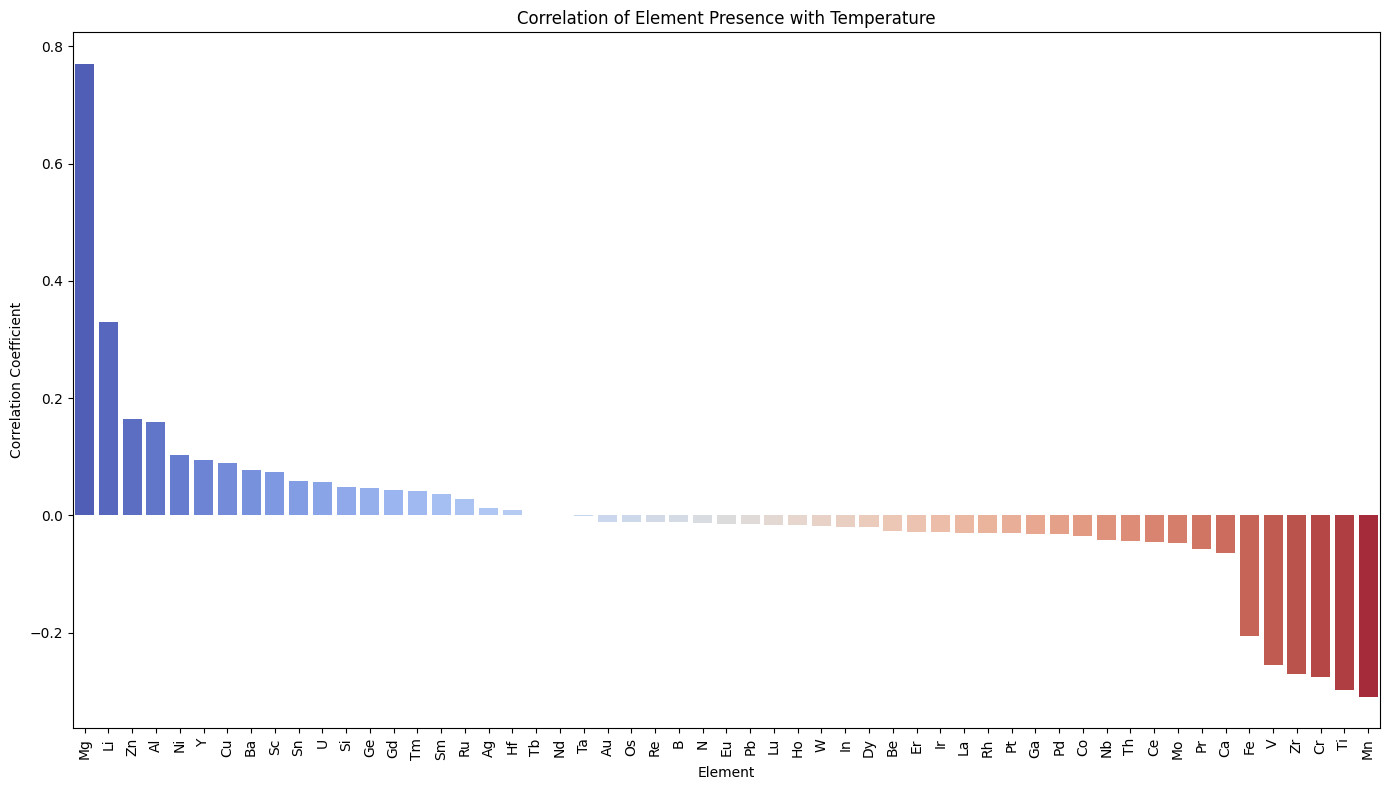

Bar chart of element correlation with temperature saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\element_correlation_with_temp.png


In [27]:
import re
from collections import defaultdict
# Function to extract elements from composition string
# This uses regex to find chemical elements (assuming standard symbols like Hf, Cu, etc.)
def extract_elements(composition):
    # Remove parentheses and other annotations like (M)
    composition = re.sub(r'\s*\(.*?\)\s*', '', composition)
    # Find sequences of capital letters followed by optional lowercase and digits
    elements = re.findall(r'([A-Z][a-z]?)(?:[0-9.]+)?', composition)
    return set(elements)  # Use set to get unique elements

# Apply extraction to create a list of elements per row
df_raw['elements'] = df_raw['Composition'].apply(extract_elements)

# Collect all unique elements across the dataset
all_elements = set()
for elems in df_raw['elements']:
    all_elements.update(elems)

# Create a dictionary to hold mean temperature for alloys containing each element
element_mean_temp = defaultdict(list)

for _, row in df_raw.iterrows():
    temp = row['temperature(K)']
    for elem in row['elements']:
        element_mean_temp[elem].append(temp)

# Compute mean temperature per element
element_means = {elem: np.mean(temps) for elem, temps in element_mean_temp.items() if len(temps) > 0}

# Convert to DataFrame for easier plotting
element_df = pd.DataFrame(list(element_means.items()), columns=['Element', 'Mean_Temperature'])
element_df = element_df.sort_values('Mean_Temperature', ascending=False)

# Bar chart of mean temperature by element
plt.figure(figsize=(14, 8))
sns.barplot(x='Element', y='Mean_Temperature', data=element_df, palette='viridis', legend=True)
plt.title('Mean Temperature by Chemical Element in Compositions')
plt.xlabel('Element')
plt.ylabel('Mean Temperature (K)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'mean_temperature_by_element.png'))
plt.show()
print("Bar chart of mean temperature by element saved at:", os.path.join(figures_path, 'mean_temperature_by_element.png'))

# To show impact more statistically, create binary features for each element
for elem in all_elements:
    df_raw[f'has_{elem}'] = df_raw['elements'].apply(lambda x: 1 if elem in x else 0)

# Compute correlation between presence of each element and temperature
element_corrs = {}
for elem in all_elements:
    corr = df_raw[f'has_{elem}'].corr(df_raw['temperature(K)'])
    element_corrs[elem] = corr

# Convert to DataFrame and sort
corr_df = pd.DataFrame(list(element_corrs.items()), columns=['Element', 'Correlation_with_Temp'])
corr_df = corr_df.sort_values('Correlation_with_Temp', ascending=False)

# Bar chart of correlation coefficients
plt.figure(figsize=(14, 8))
sns.barplot(x='Element', y='Correlation_with_Temp', data=corr_df, palette='coolwarm', legend=True)
plt.title('Correlation of Element Presence with Temperature')
plt.xlabel('Element')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'element_correlation_with_temp.png'))
plt.show()
print("Bar chart of element correlation with temperature saved at:", os.path.join(figures_path, 'element_correlation_with_temp.png'))

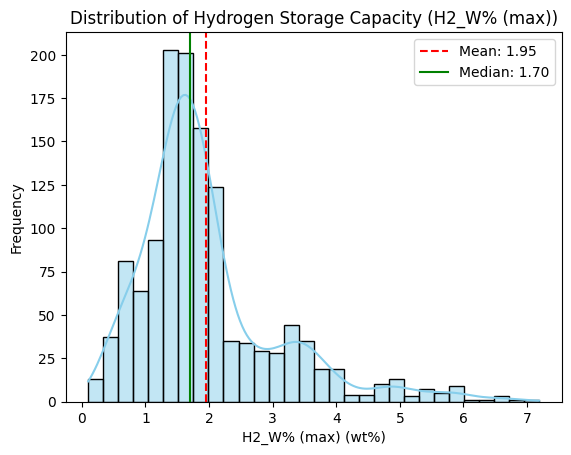

In [29]:
# Histogram of H2_W% (max) distribution with mean and median
plt.figure()
sns.histplot(df_raw['H2_W% (max)'], bins=30, kde=True, color='skyblue')
plt.axvline(df_raw['H2_W% (max)'].mean(), color='red', linestyle='--', label=f'Mean: {df_raw["H2_W% (max)"].mean():.2f}')
plt.axvline(df_raw['H2_W% (max)'].median(), color='green', linestyle='-', label=f'Median: {df_raw["H2_W% (max)"].median():.2f}')
plt.title('Distribution of Hydrogen Storage Capacity (H2_W% (max))')
plt.xlabel('H2_W% (max) (wt%)')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(figures_path, 'histogram_h2w.png'), dpi=300, bbox_inches='tight')
plt.show()

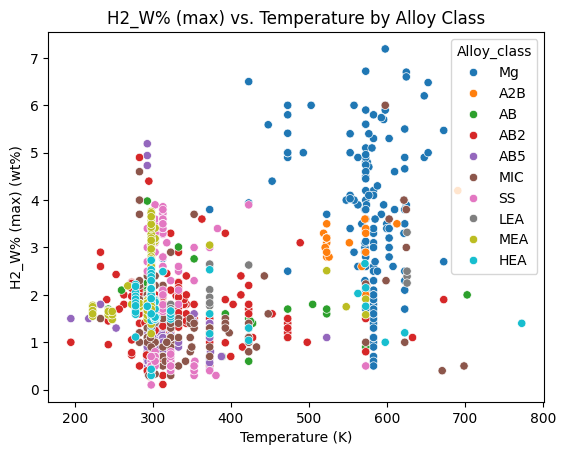

In [31]:
# Scatter plot of H2_W% (max) vs. temperature
plt.figure()
sns.scatterplot(x='temperature(K)', y='H2_W% (max)', hue='Alloy_class', data=df_raw)
plt.title('H2_W% (max) vs. Temperature by Alloy Class')
plt.xlabel('Temperature (K)')
plt.ylabel('H2_W% (max) (wt%)')
plt.savefig(os.path.join(figures_path, 'scatter_h2w_temp.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\1133734518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Alloy_class', y='H2_W% (max)', data=df_raw, palette='Set2')


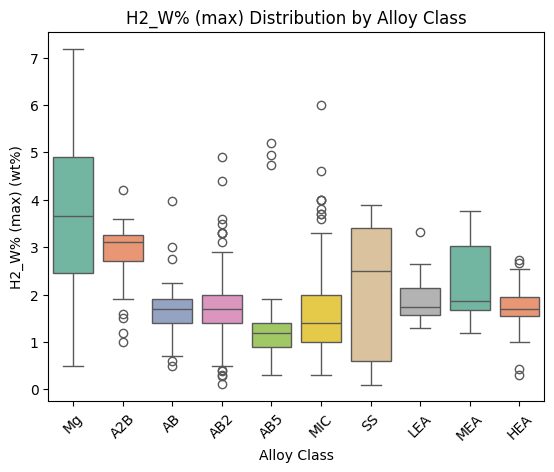

In [32]:
# Box plot of H2_W% (max) by Alloy_class
plt.figure()
sns.boxplot(x='Alloy_class', y='H2_W% (max)', data=df_raw, palette='Set2')
plt.title('H2_W% (max) Distribution by Alloy Class')
plt.xlabel('Alloy Class')
plt.ylabel('H2_W% (max) (wt%)')
plt.xticks(rotation=45)
plt.savefig(os.path.join(figures_path, 'boxplot_h2w_alloy.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\3396528273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_h2w.index, y=mean_h2w.values, palette='Set3', legend=True)


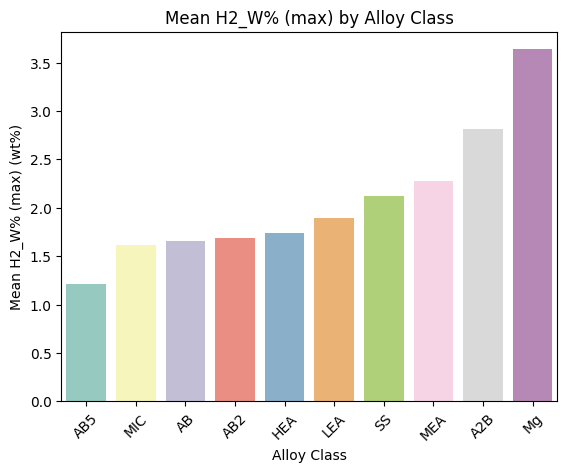

In [34]:
# Bar plot of mean H2_W% (max) by Alloy_class
mean_h2w = df_raw.groupby('Alloy_class')['H2_W% (max)'].mean().sort_values()
plt.figure()
sns.barplot(x=mean_h2w.index, y=mean_h2w.values, palette='Set3', legend=True)
plt.title('Mean H2_W% (max) by Alloy Class')
plt.xlabel('Alloy Class')
plt.ylabel('Mean H2_W% (max) (wt%)')
plt.xticks(rotation=45)
plt.savefig(os.path.join(figures_path, 'bar_mean_h2w_alloy.png'), dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\2794858002.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Element', y='Mean_Capacity', data=element_df, palette='viridis', legend=True)


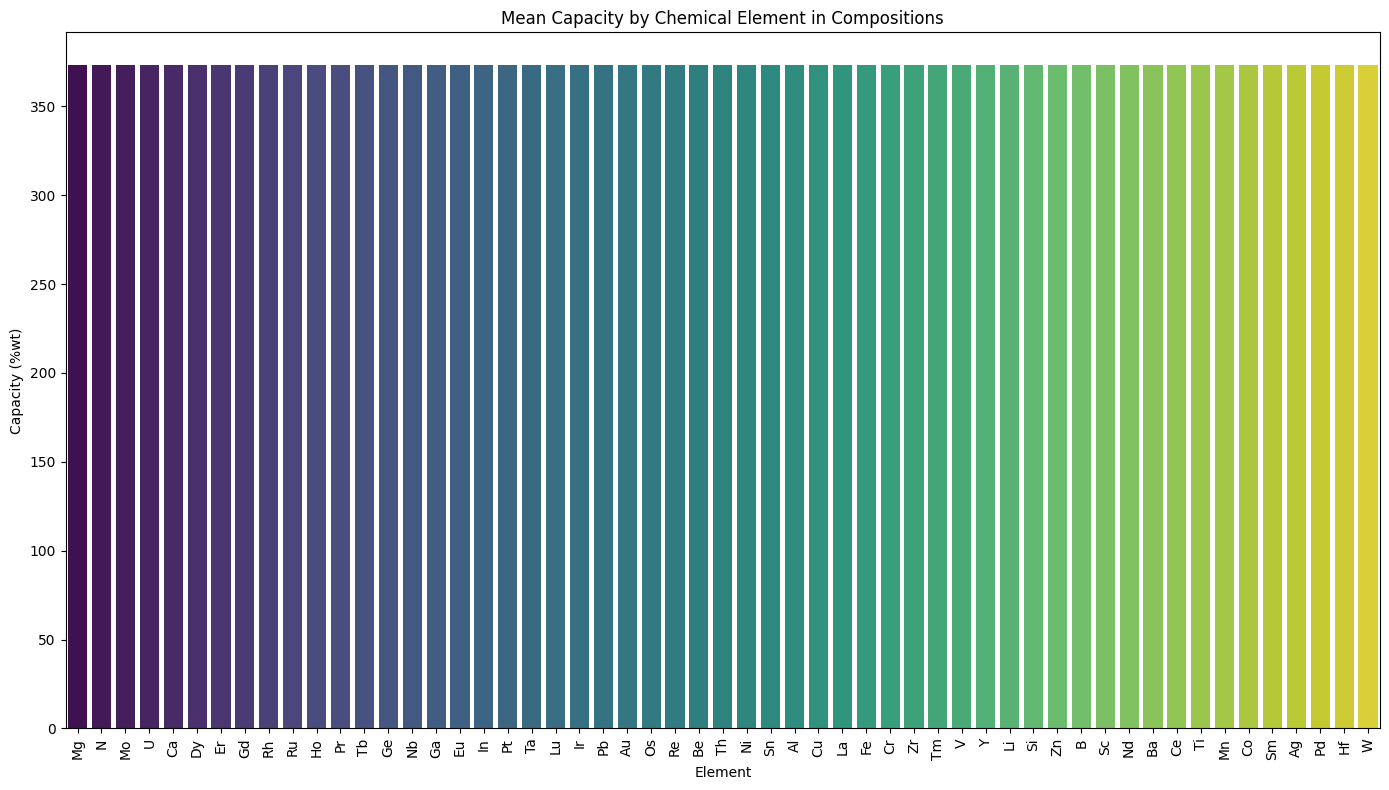

Bar chart of mean capacity by element saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\mean_capacity_by_element.png


C:\Users\Asus\AppData\Local\Temp\ipykernel_4364\2794858002.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Element', y='Correlation_with_Cap', data=corr_df, palette='coolwarm', legend=True)


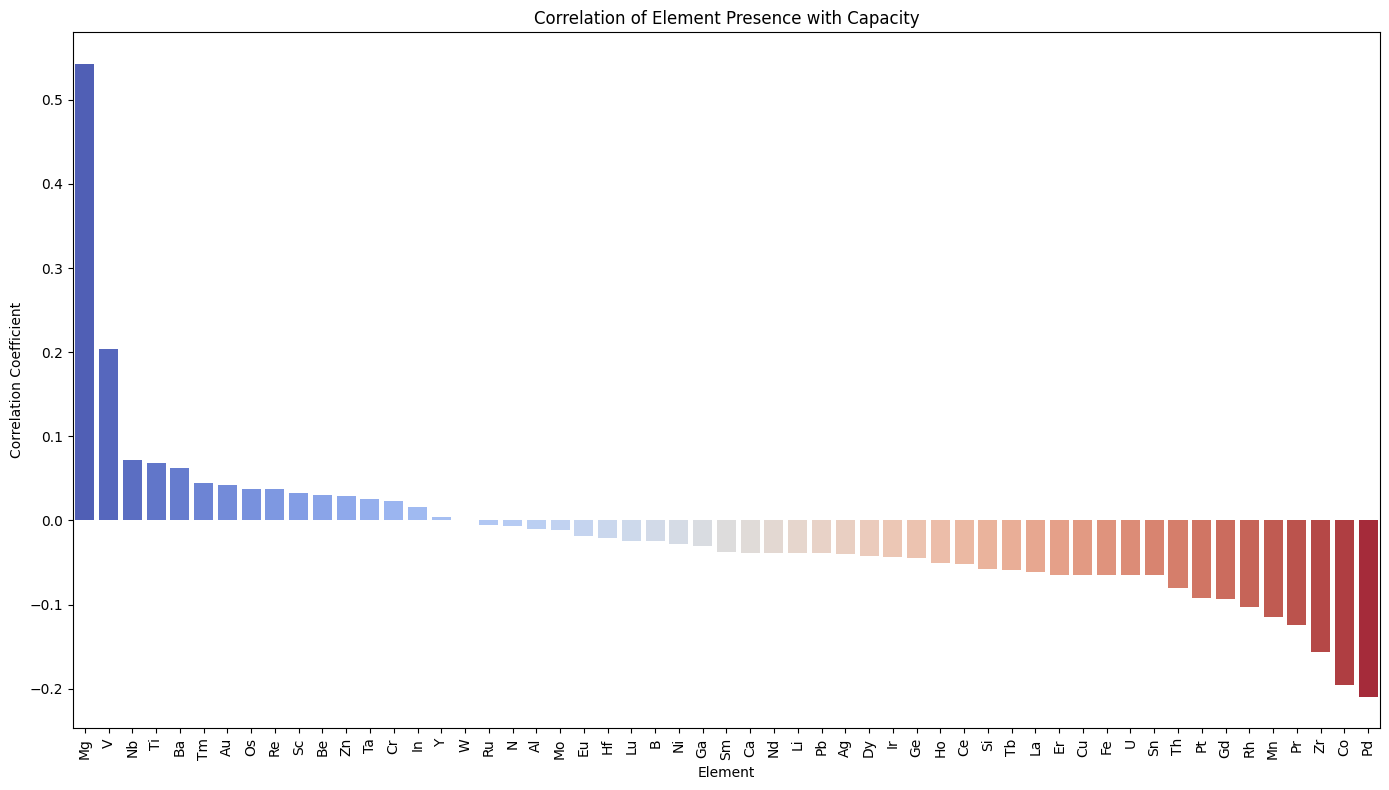

Bar chart of element correlation with capacity saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\element_correlation_with_cap.png


In [38]:
import re
from collections import defaultdict
# Function to extract elements from composition string
# This uses regex to find chemical elements (assuming standard symbols like Hf, Cu, etc.)
def extract_elements(composition):
    # Remove parentheses and other annotations like (M)
    composition = re.sub(r'\s*\(.*?\)\s*', '', composition)
    # Find sequences of capital letters followed by optional lowercase and digits
    elements = re.findall(r'([A-Z][a-z]?)(?:[0-9.]+)?', composition)
    return set(elements)  # Use set to get unique elements

# Apply extraction to create a list of elements per row
df_raw['elements'] = df_raw['Composition'].apply(extract_elements)

# Collect all unique elements across the dataset
all_elements = set()
for elems in df_raw['elements']:
    all_elements.update(elems)

# Create a dictionary to hold mean capacity for alloys containing each element
element_mean_cap = defaultdict(list)

for _, row in df_raw.iterrows():
    cap = row['H2_W% (max)']
    for elem in row['elements']:
        element_mean_cap[elem].append(temp)

# Compute mean capacity per element
element_means = {elem: np.mean(cap) for elem, cap in element_mean_cap.items() if len(cap) > 0}

# Convert to DataFrame for easier plotting
element_df = pd.DataFrame(list(element_means.items()), columns=['Element', 'Mean_Capacity'])
element_df = element_df.sort_values('Mean_Capacity', ascending=False)

# Bar chart of mean capacity by element
plt.figure(figsize=(14, 8))
sns.barplot(x='Element', y='Mean_Capacity', data=element_df, palette='viridis', legend=True)
plt.title('Mean Capacity by Chemical Element in Compositions')
plt.xlabel('Element')
plt.ylabel('Capacity (%wt)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'mean_capacity_by_element.png'))
plt.show()
print("Bar chart of mean capacity by element saved at:", os.path.join(figures_path, 'mean_capacity_by_element.png'))

# To show impact more statistically, create binary features for each element
for elem in all_elements:
    df_raw[f'has_{elem}'] = df_raw['elements'].apply(lambda x: 1 if elem in x else 0)

# Compute correlation between presence of each element and capacity
element_corrs = {}
for elem in all_elements:
    corr = df_raw[f'has_{elem}'].corr(df_raw['H2_W% (max)'])
    element_corrs[elem] = corr

# Convert to DataFrame and sort
corr_df = pd.DataFrame(list(element_corrs.items()), columns=['Element', 'Correlation_with_Cap'])
corr_df = corr_df.sort_values('Correlation_with_Cap', ascending=False)

# Bar chart of correlation coefficients
plt.figure(figsize=(14, 8))
sns.barplot(x='Element', y='Correlation_with_Cap', data=corr_df, palette='coolwarm', legend=True)
plt.title('Correlation of Element Presence with Capacity')
plt.xlabel('Element')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'element_correlation_with_cap.png'))
plt.show()
print("Bar chart of element correlation with capacity saved at:", os.path.join(figures_path, 'element_correlation_with_cap.png'))

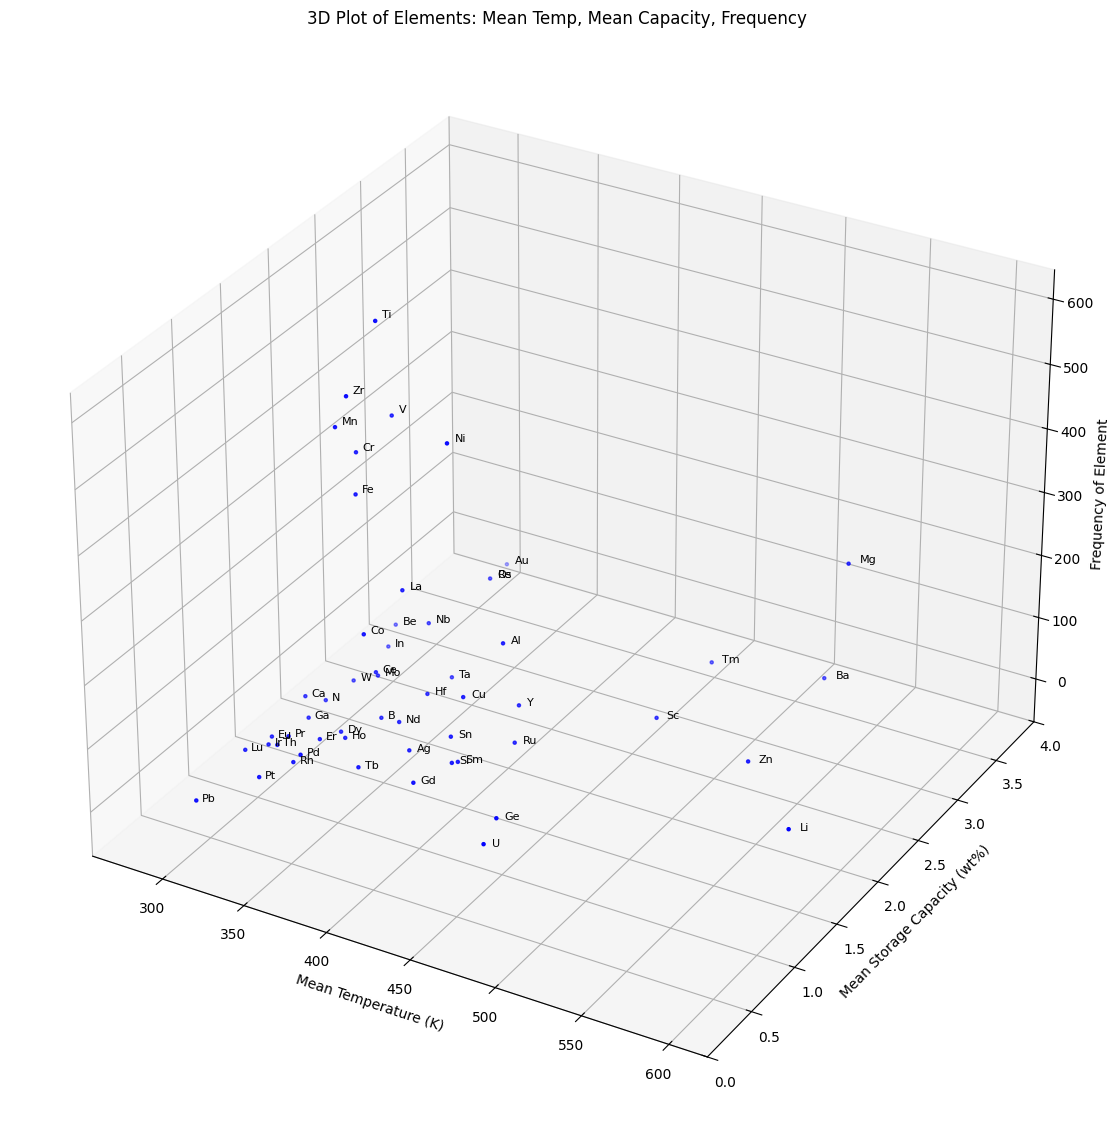

Improved 3D plot with margins saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\figures\raw_data_analysis\3d_element_temp_capacity_with_margin.png
Element stats CSV saved at: D:\Hydride_Machine_learning_project\Machine_Model\reports\element_3d_stats.csv


In [56]:
# Collect data per element: mean temp, mean capacity, frequency
element_stats = defaultdict(lambda: {'temps': [], 'capacities': [], 'count': 0})

for _, row in df_raw.iterrows():
    temp = row['temperature(K)']
    cap = row['H2_W% (max)']
    for elem in row['elements']:
        element_stats[elem]['temps'].append(temp)
        element_stats[elem]['capacities'].append(cap)
        element_stats[elem]['count'] += 1

# Compute means
data = []
for elem, stats in element_stats.items():
    if stats['temps']:
        mean_temp = np.mean(stats['temps'])
        mean_cap = np.mean(stats['capacities'])
        count = stats['count']
        data.append((elem, mean_temp, mean_cap, count))

# Convert to DataFrame
stats_df = pd.DataFrame(data, columns=['Element', 'Mean_Temp', 'Mean_Capacity', 'Frequency'])

# 3D Scatter Plot: x=Mean_Temp, y=Mean_Capacity, z=Frequency, with labels for elements
fig = plt.figure(figsize=(12, 12))  # Increased figsize for more space
ax = fig.add_subplot(111, projection='3d')

# Add label for legend
scatter = ax.scatter(stats_df['Mean_Temp'], stats_df['Mean_Capacity'], stats_df['Frequency'], c='blue', marker='.', label='Elements')

# Add labels for each point with slight offset to prevent clipping
for i, row in stats_df.iterrows():
    ax.text(row['Mean_Temp'] * 1.01, row['Mean_Capacity'] * 1.01, row['Frequency'] * 1.01, row['Element'], fontsize=8)

ax.set_xlabel('Mean Temperature (K)')
ax.set_ylabel('Mean Storage Capacity (wt%)')
ax.set_zlabel('Frequency of Element')
ax.set_title('3D Plot of Elements: Mean Temp, Mean Capacity, Frequency')

# Add legend
# ax.legend()

# Add margins to axes to prevent labels from being cut off
ax.margins(x=0.1, y=0.1, z=0.1)

# Adjust layout to add padding around the plot
plt.tight_layout(pad=3.0)

plt.savefig(os.path.join(figures_path, '3d_element_temp_capacity_with_margin.png'))
plt.show()
print("Improved 3D plot with margins saved at:", os.path.join(figures_path, '3d_element_temp_capacity_with_margin.png'))

# Save stats to CSV
stats_df.to_csv(os.path.join(report_path, 'element_3d_stats.csv'), index=False)
print("Element stats CSV saved at:", os.path.join(report_path, 'element_3d_stats.csv'))

In [57]:
# Calculate mode for temperature and capacity
temp_mode = df_raw['temperature(K)'].mode()[0] if not df_raw['temperature(K)'].mode().empty else None
capacity_mode = df_raw['H2_W% (max)'].mode()[0] if not df_raw['H2_W% (max)'].mode().empty else None

print(f"Mode of Temperature (K): {temp_mode}")
print(f"Mode of Hydrogen Storage Capacity (wt%): {capacity_mode}")

Mode of Temperature (K): 298
Mode of Hydrogen Storage Capacity (wt%): 1.6
